In [23]:
import numpy as np
import torch

In [24]:
from test_functions import Satellite
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition, entropy
from active_learning import active_learning_loop

filename = "hist.pt"
x_input = [1,1,1,1,1]

sat_prob = Satellite()
result = train_multitask_gp(sat_prob, num_train=10, seed=1111)
active_learning_loop(result,
                              acq_method = 'entropy', 
                              maxiters = 90, disp = True, 
                              save_hist = (x_input, filename),
                              log_hyperparams = True)



Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
Iter 31
Iter 32
Iter 33
Iter 34
Iter 35
Iter 36
Iter 37
Iter 38
Iter 39
Iter 40
Iter 41
Iter 42
Iter 43
Iter 44
Iter 45
Iter 46
Iter 47
Iter 48
Iter 49
Iter 50
Iter 51
Iter 52
Iter 53
Iter 54
Iter 55
Iter 56
Iter 57
Iter 58
Iter 59
Iter 60
Iter 61
Iter 62
Iter 63
Iter 64
Iter 65
Iter 66
Iter 67
Iter 68
Iter 69
Iter 70
Iter 71
Iter 72
Iter 73


C:\Users\kaily\miniconda3\envs\bayesian_opt\Lib\site-packages\botorch\fit.py:215: OptimizationWarning: `scipy_minimize` terminated with status OptimizationStatus.FAILURE, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)


Iter 74
Iter 75
Iter 76
Iter 77
Iter 78
Iter 79
Iter 80
Iter 81
Iter 82
Iter 83
Iter 84
Iter 85
Iter 86
Iter 87
Iter 88
Iter 89
Iter 90
done


Text(0, 0.5, 'distance from openMDAO result')

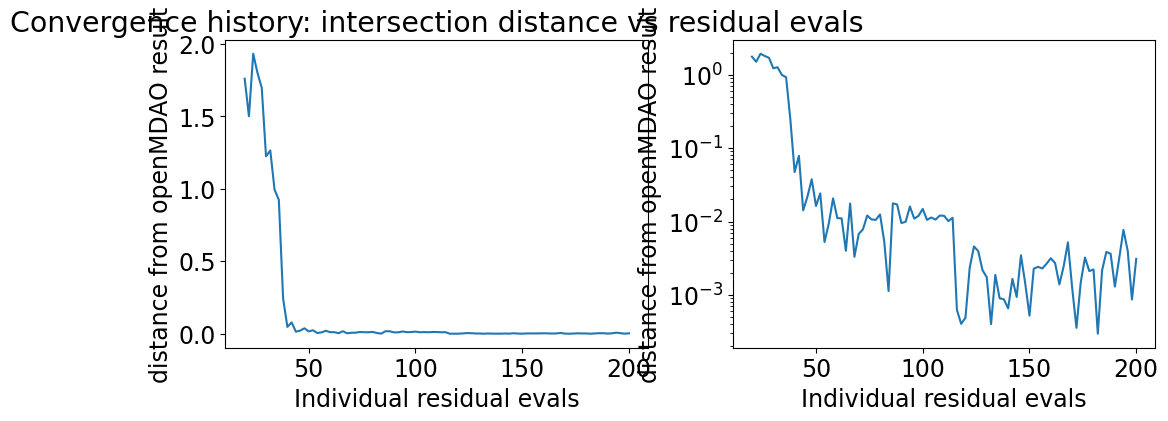

In [25]:
import torch
import matplotlib.pyplot as plt

fail_index = []

history = torch.load("hist.pt")
num_evals = history["num_evals"]
dist_history = history["dist_history"]

fig = plt.figure(figsize=(12,4))

host = fig.add_subplot(121)
plt.plot(num_evals, dist_history)
for ind in fail_index:
    plt.plot([20+2*ind, 20+2*ind], [0,1.75], ':k')
host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

host = fig.add_subplot(122)
plt.semilogy(num_evals, dist_history)
for ind in fail_index:
    plt.plot([20+2*ind, 20+2*ind], [0.0001, 1], ':k')
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

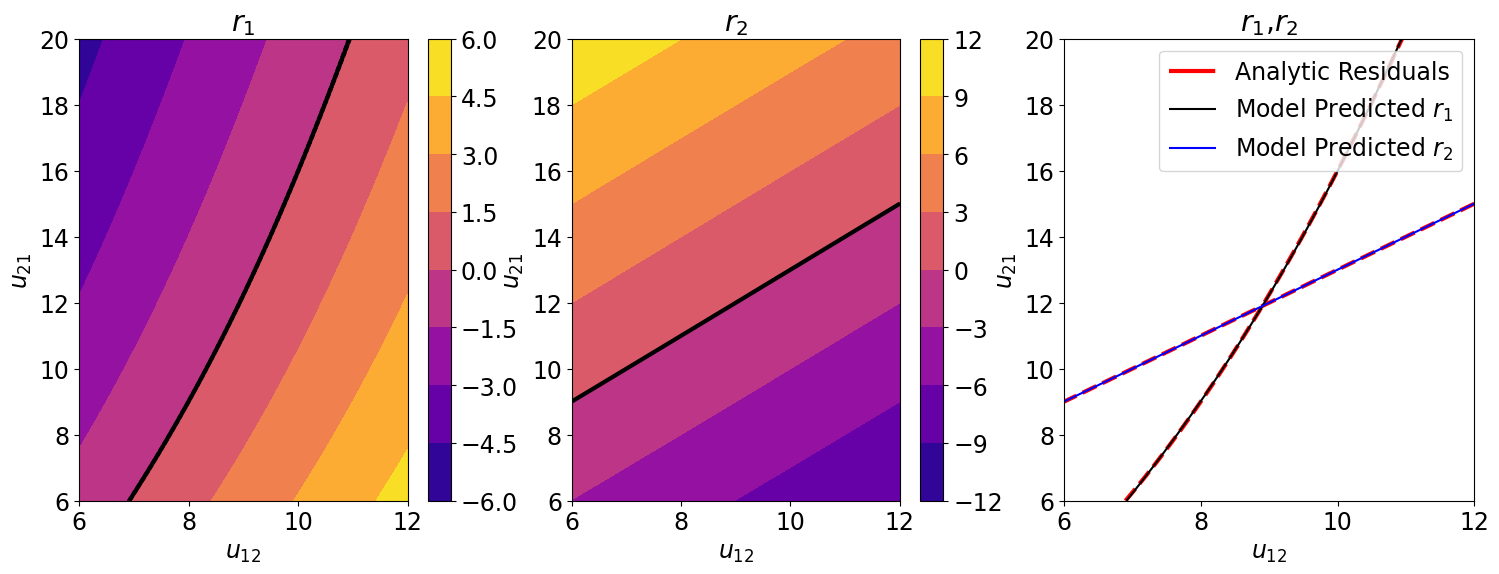

In [40]:
import matplotlib.pyplot as plt
import torch
from botorch.utils.transforms import normalize

mt_model = result.model
y = result.train_y
bounds = sat_prob.bounds

input_vec = torch.tensor(x_input)
npts = 40
# xvec is u12, yvec is u21
xvec, yvec = torch.meshgrid(torch.linspace(6.,12.,npts), torch.linspace(6.,20.,npts), indexing='ij')

# Analytic
sat_prob.set_vars(torch.column_stack([input_vec.repeat(1600,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = sat_prob.res[:,0]
r2vec = sat_prob.res[:,1]

# Predictions
test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                             xvec.reshape(-1,1),
                             yvec.reshape(-1,1)])
test_x = normalize(test_x,bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
# test_x1.requires_grad = True

prediction1 = y.mean().item()+(mt_model.likelihood(mt_model(test_x1)))*y.std().item()
prediction2 = y.mean().item()+(mt_model.likelihood(mt_model(test_x2)))*y.std().item()

fig = plt.figure(figsize=(18,6))

# r1
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(40,40),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(40,40), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(40, 40) + 2.* prediction1.stddev.detach().reshape(40, 40), levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(40, 40) - 2.* prediction1.stddev.detach().reshape(40, 40), levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$u_{12}$')
ax1.set_ylabel(r'$u_{21}$')

# r2
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(40,40),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(40,40), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(40, 40) + 2.* prediction2.stddev.detach().reshape(40, 40), levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(40, 40) - 2.* prediction2.stddev.detach().reshape(40, 40), levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2)
ax2.set_title(r'$r_2$')
ax2.set_xlabel(r'$u_{12}$')
ax2.set_ylabel(r'$u_{21}$')

# both
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
#              cmap = 'plasma')
# fig.colorbar(cf3)
s1 = ax3.contour(xvec,yvec,r1vec.reshape(40,40),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(40,40),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(40,40),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(40,40),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='b')
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$,$r_2$')
ax3.set_xlabel(r'$u_{12}$')
ax3.set_ylabel(r'$u_{21}$')
#ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])

In [2]:
from test_functions import Satellite
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition, entropy
from active_learning import active_learning_loop

x_input = torch.rand(10,5)

for i in range(0,20):
    print("hist"+str(i))
    filename = "hist" + str(i) + ".pt"
    sat_prob = Satellite()
    result = train_multitask_gp(sat_prob, num_train=10, seed=1111)
    active_learning_loop(result,
                         acq_method = 'entropy', 
                         maxiters = 30, disp = True, 
                         save_hist = (x_input, filename))



hist0


C:\Users\kaily\miniconda3\envs\bayesian_opt\Lib\site-packages\linear_operator\utils\interpolation.py:71: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\bld\libtorch_1753839225953\work\torch\csrc\utils\tensor_new.cpp:656.)
  summing_matrix = cls(summing_matrix_indices, summing_matrix_values, size)
C:\Users\kaily\Desktop\Research\Jupyter Notebooks\MDAO Bayesian Opt\ActiveLearning\active_learning.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_list = torch.tensor(save_hist[0]).reshape(-1,input_dim)


Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
hist1


C:\Users\kaily\Desktop\Research\Jupyter Notebooks\MDAO Bayesian Opt\ActiveLearning\active_learning.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_list = torch.tensor(save_hist[0]).reshape(-1,input_dim)


Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
hist2


...

Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
hist18


C:\Users\kaily\Desktop\Research\Jupyter Notebooks\MDAO Bayesian Opt\ActiveLearning\active_learning.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_list = torch.tensor(save_hist[0]).reshape(-1,input_dim)


Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
hist19


C:\Users\kaily\Desktop\Research\Jupyter Notebooks\MDAO Bayesian Opt\ActiveLearning\active_learning.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_list = torch.tensor(save_hist[0]).reshape(-1,input_dim)


Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done


Text(0, 0.5, 'Distance from OpenMDAO result')

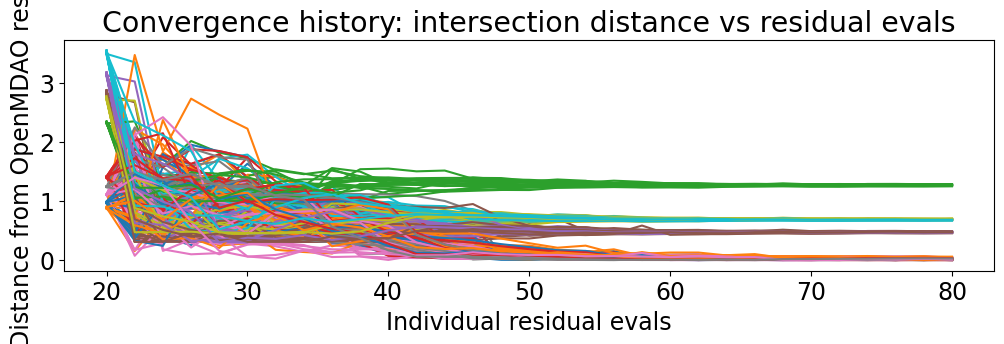

In [21]:
import torch
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,3))
host = fig.add_subplot(111)

for i in range(0,20):
    history = torch.load("hist" + str(i) + ".pt")
    num_evals = history["num_evals"]
    dist_history = history["dist_history"]

    plt.plot(num_evals, dist_history)

# plt.axvline(x=40, color='red', linestyle='--', label="NLBGS Converged"

host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('Distance from OpenMDAO result')

## Note: intersection distance converging to values larger than about 1E-2 indiciates that the intersection point occurs outside the bounds of the problem. This needs to be addressed. For example:

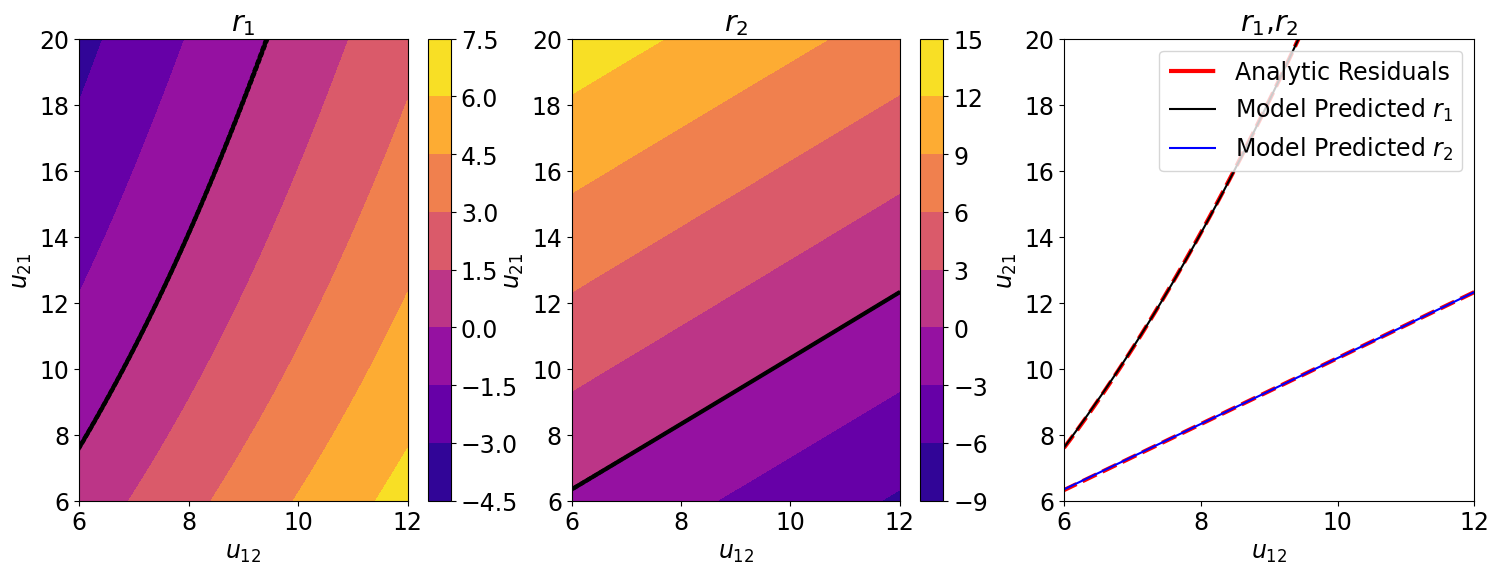

In [39]:
import matplotlib.pyplot as plt
import torch
from botorch.utils.transforms import normalize

mt_model = result.model
y = result.train_y
bounds = sat_prob.bounds

input_vec = torch.tensor([0.4074, 0.5940, 0.8677, 0.3936, 0.0059])
npts = 40
# xvec is u12, yvec is u21
xvec, yvec = torch.meshgrid(torch.linspace(6.,12.,npts), torch.linspace(6.,20.,npts), indexing='ij')

# Analytic
sat_prob.set_vars(torch.column_stack([input_vec.repeat(1600,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = sat_prob.res[:,0]
r2vec = sat_prob.res[:,1]

# Predictions
test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                             xvec.reshape(-1,1),
                             yvec.reshape(-1,1)])
test_x = normalize(test_x,bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
# test_x1.requires_grad = True

prediction1 = y.mean().item()+(mt_model.likelihood(mt_model(test_x1)))*y.std().item()
prediction2 = y.mean().item()+(mt_model.likelihood(mt_model(test_x2)))*y.std().item()

fig = plt.figure(figsize=(18,6))

# r1
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(40,40),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(40,40), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(40, 40) + 2.* prediction1.stddev.detach().reshape(40, 40), levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(40, 40) - 2.* prediction1.stddev.detach().reshape(40, 40), levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$u_{12}$')
ax1.set_ylabel(r'$u_{21}$')

# r2
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(40,40),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(40,40), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(40, 40) + 2.* prediction2.stddev.detach().reshape(40, 40), levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(40, 40) - 2.* prediction2.stddev.detach().reshape(40, 40), levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2)
ax2.set_title(r'$r_2$')
ax2.set_xlabel(r'$u_{12}$')
ax2.set_ylabel(r'$u_{21}$')

# both
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
#              cmap = 'plasma')
# fig.colorbar(cf3)
s1 = ax3.contour(xvec,yvec,r1vec.reshape(40,40),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(40,40),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(40,40),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(40,40),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='b')
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$,$r_2$')
ax3.set_xlabel(r'$u_{12}$')
ax3.set_ylabel(r'$u_{21}$')
#ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])